In [1]:
import numpy as np 
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import myfun as wf
import math, gc, logging,os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import geocat.viz as gv

In [2]:
if __name__ == "__main__":
    fpath_in0 = "/glade/derecho/scratch/hcluo/v800_variance/"
    years = np.arange(1997,2024)
    BOUNDARY  = [-30,30,0,360]    
    fnames1 = []
    
    for i in years:
        fnames1.append(fpath_in0+"v800_variance_"+str(i)+".nc")

In [3]:
ds1 = xr.open_mfdataset(fnames1,concat_dim = 'time', combine='nested')["v800_variance"]
print(ds1)

<xarray.DataArray 'v800_variance' (time: 27, latitude: 121, longitude: 720)> Size: 19MB
dask.array<concatenate, shape=(27, 121, 720), dtype=float64, chunksize=(1, 121, 720), chunktype=numpy.ndarray>
Coordinates:
    level      float64 8B 800.0
  * latitude   (latitude) float64 968B -30.0 -29.5 -29.0 ... 29.0 29.5 30.0
  * longitude  (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Dimensions without coordinates: time


DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x7fdc8419bfd0>
DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'
DEBUG:matplotlib.backends.backend_pdf:Assigning font /F2 = '/glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Oblique.ttf'
DEBUG:matplotlib.backends.backend_pdf:Assigning font /F3 = '/glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/cmsy10.ttf'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Oblique.ttf.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.
DEBUG:matplotlib.backends.backend_pdf:Embedding font /glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf.
DEBUG:matplotlib.b

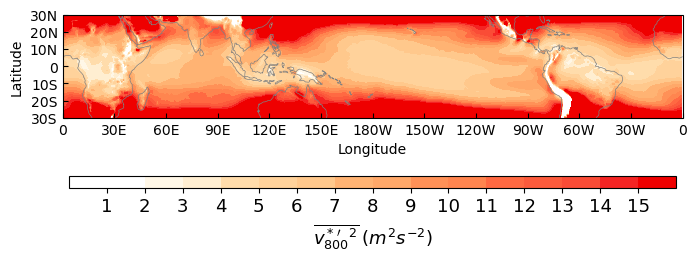

In [10]:
lb_ticks = np.linspace(1,15,15)
x_ticks = np.arange(-180,180+30,30)
y_ticks = np.arange(BOUNDARY[0],BOUNDARY[1]+10,10)
x_labels = [f"{abs(lon)}W" if lon < 0 else (f"{lon}" if lon == 0 else f"{lon}E") for lon in ((x_ticks+360)% 360 - 180)]
y_labels = [f"{abs(lat)}S" if lat < 0 else (f"{lat}" if lat == 0 else f"{lat}N") for lat in y_ticks]
    
fig, ax = plt.subplots(
        nrows=1, ncols=1,
        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
        figsize=(8, 5)
    )

shadings = ax.contourf(ds1.longitude-180, ds1.latitude, ds1.mean("time"),
                       levels=lb_ticks,
                       extend='both',
                       cmap = wf.colormap(color="WhiRed"))
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Longitude")
ax.set_ylim([y_ticks[0],y_ticks[-1]])
ax.coastlines(linewidth=0.5, zorder=1,color='gray')
ax.tick_params(direction='in', which='both')
    
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_ylabel("Latitude")
cbar = plt.colorbar(shadings,ax=ax,
                                 extendrect = True,
                                 extendfrac = 'auto',
                                 orientation='horizontal',
                                 ticks=lb_ticks,
                                 shrink=0.98,
                                 aspect = 50,
                                 drawedges=False)#,
                                 #pad=0.04)
cbar.ax.tick_params(labelsize=13)
cbar.ax.xaxis.set_label_position('bottom')
cbar.set_label(label=r"$\overline{v_{800}^*'^2} \; ( m^2 s^{-2})$", size=13,loc = 'center')
plt.savefig("climatology_v800_variance_plot.pdf",bbox_inches='tight')